In [212]:
import xarray as xr
import numpy as np
import numpy.ma as ma
from datetime import datetime as dt
from datetime import timedelta

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import glob, sys, os, re
from pprint import pprint
import warnings
import pickle

In [213]:
sim_dir = "/lustre/fsn1/projects/rech/lsv/ubd61nl/ObedSaba_RECONCILE_MesoNH/production/WPAGG_2km"
fig_dir = '../figures'
out_dir = '../results'

In [3]:
# Define simulation subfolders
sim_names = [f for f in os.listdir(sim_dir) if re.match("(.*)2016(.*)",f) ]
sim_names.sort(reverse=True)
print(sim_names)

['t0_20160910_00', 'p6_20160910_06', 'p12_20160910_12']


In [35]:
# Input time info
time_freq_MNH = 1200 # s
time_freq_GOESW = 1800 # s
time_step_MNH = 3 # s

# Simulation lag info
lags_h = np.array([0,6,12])
lag_6h = timedelta(seconds=6*3600)
lag_12h = timedelta(seconds=12*3600)

# Conversion factors
s_to_h = 1/3600
rho_w = 1e3 # km/m3
m_to_mm = 1e3 

In [203]:
# # Load all sims at a specific time

# def getFileAtTime(target_time,time_ref=dt(2016,9,10),lag_h=0):
#     """For a given lag (in hours) at the start of the simulation,
#     get the filename of the right simulation at that given time.
#     """
    
#     i_lag = np.where(lags_h == lag_h)[0][0]
    
#     #-- get corresponding time file
#     # time difference
#     delta_t = target_time - (time_ref+timedelta(seconds=lag_h*3600))
#     # find corresponding subfolder
#     i_seg = int((delta_t.total_seconds()/3600/Dt - 1) / (12/Dt) ) +1 # segment number
#     subfolder = "seg0%d_12h_tege"%i_seg
#     # build corresponding filename
#     i_t_seg = int((delta_t.total_seconds()/3600/Dt - 1) % int(12/Dt) + 1)
#     filename = "FBC01.1.MNH0%d.OUT.%s.nc"%(i_seg,str(i_t_seg).zfill(3))
#     # full path
#     path = os.path.join(sim_dir,sim_names[i_lag],subfolder,filename)

#     return path

#- MNH File identification

def getMNHFileAtTime(target_time,time_ref=dt(2016,9,10),lag_h=0):
    """For a given lag (in hours) at the start of the simulation,
    get the filename of the right simulation at that given time.
    """
    
    # simulation index
    i_lag = np.where(lags_h == lag_h)[0][0]
    # simulation output hourly frequency
    Dt = time_freq_MNH/3600
    
    #-- get corresponding time file
    # time difference
    delta_t = target_time - (time_ref+timedelta(seconds=lag_h*3600))
    if delta_t.total_seconds() >= 0:
        # number of output steps
        n_out = int(delta_t.total_seconds()/3600/Dt - 1)
        # compute corresponding subfolder number
        i_seg = floor(n_out / (12/Dt) ) +1 # segment number
        # compute corresponding file step
        i_t_seg = int(n_out % int(12/Dt) + 1)
        # build corresponding subfolder
        subfolder = "seg0%d_12h_tege"%i_seg
        # build corresponding filename
        filename = "FBC01.1.MNH0%d.OUT.%s.nc"%(i_seg,str(i_t_seg).zfill(3))
        # full path
        path = os.path.join(sim_dir,sim_names[i_lag],subfolder,filename)
        
    else:
        path = None

    return path

#- Adjust target time for file selection

def getAdjustedTime(target_time,time_freq=1800):
    """Adjust the target datetime to the current time, according to the frequency of data files.

    Args:
    - target_time (datetime object): target time
    - time_freq (float): frequency of the data files, in s

    Returns:
    - adjusted time (datetime object): adjusted time on the data files time array.
    """

    # compute the number of seconds of IMERG file since start of day
    n_steps = int((target_time-dt(target_time.year,target_time.month,target_time.day)).seconds / (time_freq))
    adjusted_seconds = int(n_steps * time_freq)
    # adjusted time
    adjusted_time = dt(target_time.year,target_time.month,target_time.day)+timedelta(seconds=adjusted_seconds)

    return adjusted_time

#- Conversion to string

def dateToStr(dt:datetime,fmt="%Y%m%dT%H%M"):

    return dt.strftime(fmt)

In [9]:
#- Conversions between OLR and Tb

def getOLRFromTb(Tb):
    """Compute OLR estimate in W/m2 from Tb in K, using the conversion formula from Ohring & Gruber (1984),
    with coefficients reported in Yang & Slingo (2001), also used in Feng et al. (2024):

    OLR = sigma * Tf^4

    where

    Tf = Tb * (a + b Tb)

    with a = 1.228 and b = -1.106e-3 K-1.
    """

    sigma = 5.67e-8 # W/m2/K4
    a = 1.228 # no unit
    b = -1.106e-3 # K-1
    
    return sigma * (a * Tb + b * Tb**2)**4

def getTbFromOLR(OLR):
    """Compute Tb estimate in K from OLR in W/m2, by reverting the conversion formula from Ohring & Gruber (1984),
    with coefficients reported in Yang & Slingo (2001), also used in Feng et al. (2024):

    OLR = sigma * Tf^4

    where

    Tf = Tb * (a + b Tb)

    with a = 1.228 and b = -1.106e-3 K-1.
    """

    sigma = 5.67e-8 # W/m2/K4
    a = 1.228 # no unit
    b = -1.106e-3 # K-1
    
    return (-a + np.sqrt(a**2 + 4 * b* (OLR/sigma)**(1/4)))/(2*b)

In [6]:
# time to show
target_time = dt(2016,9,10,14,00)
# Adjusted time on MNH time array
target_time_MNH = getAdjustedTime(target_time,time_freq_MNH)

In [182]:
def getDataset(filepath):

    if filepath is not None and not re.match(r".*000.nc", filepath):
        if len(glob.glob(filepath)) > 0 :
            with warnings.catch_warnings(action="ignore"):
                return xr.open_dataset(filepath)
    else:
        return None

def computeFractionOLR(dataset,var_thres):

    if dataset is not None:
            
        # get data
        var = dataset.RLUT_INST[0]
        # compute fraction
        frac = (np.sum(var < var_thres)/var.size).values

    else:

        frac = None

    return frac

## __ Dev __

In [ ]:
##-- Get Meso-NH data and coords

#- Datasets
data_lag0 = getDataset(getMNHFileAtTime(target_time_MNH,lag_h=0))
data_lag6 = getDataset(getMNHFileAtTime(target_time_MNH,lag_h=6))
data_lag12 = getDataset(getMNHFileAtTime(target_time_MNH,lag_h=12))


In [12]:
#- Define threshold OLR
Tb_ref = 235 # K
OLR_ref = getOLRFromTb(Tb_ref)
print('thredhold OLR =', OLR_ref,'W/m2')

thredhold OLR = 151.88589483794564 W/m2


In [32]:
##-- Compute the domain fraction exceeding Tb=235K (OLR=152 W/m2)

# fraction below OLR_ref
RLUT_frac_lag0 = computeFractionOLR(data_lag0,OLR_ref)
RLUT_frac_lag6 = computeFractionOLR(data_lag6,OLR_ref)
RLUT_frac_lag12 = computeFractionOLR(data_lag12,OLR_ref)

print('Simulated anvil fraction:',RLUT_frac_lag0, RLUT_frac_lag6, RLUT_frac_lag12)

Simulated anvil fraction: 0.11845138888888888 0.10353888888888889 0.07924097222222222


In [41]:
##-- Get GOES-W Tb data, convert it to OLR, and crop to target domain
    
#- Path to observed GOES-W Tb
#
# Data copied to jeanzay from spirit1:/bdd/GEOgrid_coldcloud/
#

def getDataAtTimeGOESW(target_time):
    
    # define observations data path
    parent_dir = '/lustre/fswork/projects/rech/lsv/uae56hc/observations/GEOgrid_coldcloud/GOES-W-1350'
    data_dir = os.path.join(parent_dir,str(target_time.year),target_time.strftime("%Y_%m_%d"))
    # create file name
    file_name = 'GEO_L1C-GOES15_%s-00_G_IR107_004_V1.1.nc'%target_time.strftime("%Y-%m-%dT%H-%M")
    # create file path 
    file_path = os.path.join(data_dir,file_name)
    # Load dataset
    if len(glob.glob(file_path)) > 0 :
        with warnings.catch_warnings(action="ignore"):
            data_obs = xr.open_dataset(file_path)
    else:
        data_obs = None

    return data_obs

In [186]:
##-- Compute the fraction of the domain exceeding Tb=235K (OLR=152 W/m2)

def computeDomainFractionGOESW(data_lag0,data_obs,Tb_ref):
    
    #- Domain coords
    
    if data_lag0 is not None:
        
        lon_array = data_lag0.longitude.values
        lat_array = data_lag0.latitude.values
        longitude = data_lag0.longitude[0].values
        latitude = data_lag0.latitude[:,0].values
        extent = [longitude[0],longitude[-1],latitude[0],latitude[-1]]
        
        # Select the same region as in Meso-NH
        lon_slice = slice(extent[0]+360,extent[1]+360)
        lat_slice = slice(extent[3],extent[2])
    
    else :
        lon_slice = lat_slice = slice(None)
    
    if data_obs is not None:
        
        # Get variable
        Tb_obs = data_obs.Harmonized_irBT.sel(longitude=lon_slice,latitude=lat_slice)
        
        # Compute fraction below Tb
        Tb_frac_obs = (np.sum(Tb_obs < Tb_ref)/Tb_obs.size).values
    
    else:
    
        Tb_frac_obs = None

    return Tb_frac_obs
    


In [87]:
target_time = dt(2016,9,10,14)
# get data
data_obs = getDataAtTimeGOESW(target_time)
# compute fraction
frac_obs = computeDomainFractionGOESW(data_lag0,data_obs,Tb_ref)

print('Observed anvil fraction:',Tb_frac_obs)

Observed anvil fraction: 0.15257536501767738


## __ Time iteration __

In [77]:
def toStr(value):
    """Format float or None to string"""

    if value is not None:
        return f"{value:,.4f}"
    else:
        return ''
        

In [192]:
# Check which files are being opened

for i_t in range(N_t):

    # time to show
    target_time = time_ref + i_t*t_delta
    # Adjusted time on MNH time array
    target_time_MNH = getAdjustedTime(target_time,time_freq_MNH)
    # Adjusted time on GOES-W time array
    target_time_GOESW = getAdjustedTime(target_time,time_freq_GOESW)
    # Get MNH filenames
    filename_MNH_lag0 = getMNHFileAtTime(target_time_MNH,lag_h=0)
    filename_MNH_lag6 = getMNHFileAtTime(target_time_MNH,lag_h=6)
    filename_MNH_lag12 = getMNHFileAtTime(target_time_MNH,lag_h=12)

    print(dateToStr(target_time))
    print(filename_MNH_lag0)
    print(filename_MNH_lag6)
    print(filename_MNH_lag12)

20160910T0000
/lustre/fsn1/projects/rech/lsv/ubd61nl/ObedSaba_RECONCILE_MesoNH/production/WPAGG_2km/t0_20160910_00/seg01_12h_tege/FBC01.1.MNH01.OUT.001.nc
/lustre/fsn1/projects/rech/lsv/ubd61nl/ObedSaba_RECONCILE_MesoNH/production/WPAGG_2km/p6_20160910_06/seg01_12h_tege/FBC01.1.MNH01.OUT.001.nc
/lustre/fsn1/projects/rech/lsv/ubd61nl/ObedSaba_RECONCILE_MesoNH/production/WPAGG_2km/p12_20160910_12/seg01_12h_tege/FBC01.1.MNH01.OUT.001.nc
20160910T0010
/lustre/fsn1/projects/rech/lsv/ubd61nl/ObedSaba_RECONCILE_MesoNH/production/WPAGG_2km/t0_20160910_00/seg01_12h_tege/FBC01.1.MNH01.OUT.001.nc
/lustre/fsn1/projects/rech/lsv/ubd61nl/ObedSaba_RECONCILE_MesoNH/production/WPAGG_2km/p6_20160910_06/seg01_12h_tege/FBC01.1.MNH01.OUT.001.nc
/lustre/fsn1/projects/rech/lsv/ubd61nl/ObedSaba_RECONCILE_MesoNH/production/WPAGG_2km/p12_20160910_12/seg01_12h_tege/FBC01.1.MNH01.OUT.001.nc
20160910T0020
/lustre/fsn1/projects/rech/lsv/ubd61nl/ObedSaba_RECONCILE_MesoNH/production/WPAGG_2km/t0_20160910_00/seg01_12h

In [210]:
##-- Load data ref MNH for domain information
# reference time with valid MNH data
valid_time = dt(2016,9,10,12,00)
# valid data
data_ref_MNH = getDataset(getMNHFileAtTime(valid_time))

##-- Compute domain fraction at all times

N_t = int(6*24*1.5) # Number of time slices
t_delta = timedelta(seconds=600) # 10-minute increments
time_ref = dt(2016,9,10)

# Initialize array of anvil fractions
frac_array = np.full((4,N_t),np.nan)

# Iterate over time
for i_t in range(N_t):

    # time to show
    target_time = time_ref + i_t*t_delta
    # Adjusted time on MNH time array
    target_time_MNH = getAdjustedTime(target_time,time_freq_MNH)
    # Adjusted time on GOES-W time array
    target_time_GOESW = getAdjustedTime(target_time,time_freq_GOESW)

    # Get data for GOES-W
    data_obs = getDataAtTimeGOESW(target_time_GOESW)
    # Compute domain fractions for GOES-W
    frac_obs = computeDomainFractionGOESW(data_ref_MNH,data_obs,Tb_ref)
    
    # Get data for MNH
    data_lag0 = getDataset(getMNHFileAtTime(target_time_MNH,lag_h=0))
    data_lag6 = getDataset(getMNHFileAtTime(target_time_MNH,lag_h=6))
    data_lag12 = getDataset(getMNHFileAtTime(target_time_MNH,lag_h=12))

    # Compute fraction for MNH
    frac_lag0 = computeFractionOLR(data_lag0,OLR_ref)
    frac_lag6 = computeFractionOLR(data_lag6,OLR_ref)
    frac_lag12 = computeFractionOLR(data_lag12,OLR_ref)

    # Save calculation
    frac_array[0,i_t] = frac_obs
    frac_array[1,i_t] = frac_lag0
    frac_array[2,i_t] = frac_lag6
    frac_array[3,i_t] = frac_lag12
    
    print("%s : MNH at %s, GOES-W at %s -- Obs: %s ; MNH t0: %s ; MNH t0+6h: %s ; MNH t0+12h: %s ; "%(dateToStr(target_time),
                                                                                                      dateToStr(target_time_MNH),
                                                                                                      dateToStr(target_time_GOESW),
                                                                                                      toStr(frac_obs),
                                                                                                      toStr(frac_lag0),
                                                                                                      toStr(frac_lag6),
                                                                                                      toStr(frac_lag12)))
    

20160910T0000 : MNH at 20160910T0000, GOES-W at 20160910T0000 -- Obs: 0.0784 ; MNH t0:  ; MNH t0+6h:  ; MNH t0+12h:  ; 
20160910T0010 : MNH at 20160910T0000, GOES-W at 20160910T0000 -- Obs: 0.0784 ; MNH t0:  ; MNH t0+6h:  ; MNH t0+12h:  ; 
20160910T0020 : MNH at 20160910T0020, GOES-W at 20160910T0000 -- Obs: 0.0784 ; MNH t0: 0.0133 ; MNH t0+6h:  ; MNH t0+12h:  ; 
20160910T0030 : MNH at 20160910T0020, GOES-W at 20160910T0030 -- Obs: 0.0810 ; MNH t0: 0.0133 ; MNH t0+6h:  ; MNH t0+12h:  ; 
20160910T0040 : MNH at 20160910T0040, GOES-W at 20160910T0030 -- Obs: 0.0810 ; MNH t0: 0.0268 ; MNH t0+6h:  ; MNH t0+12h:  ; 
20160910T0050 : MNH at 20160910T0040, GOES-W at 20160910T0030 -- Obs: 0.0810 ; MNH t0: 0.0268 ; MNH t0+6h:  ; MNH t0+12h:  ; 
20160910T0100 : MNH at 20160910T0100, GOES-W at 20160910T0100 -- Obs: 0.0845 ; MNH t0: 0.0385 ; MNH t0+6h:  ; MNH t0+12h:  ; 
20160910T0110 : MNH at 20160910T0100, GOES-W at 20160910T0100 -- Obs: 0.0845 ; MNH t0: 0.0385 ; MNH t0+6h:  ; MNH t0+12h:  ; 
2016

In [218]:
##-- Store calculation results on disk
pickle.dump(frac_array,open(os.path.join(out_dir,'RC5_frac_Tb_235_GOESW_t0_t6_t12.pickle'),'wb'))

In [229]:
# Time array
time_array = np.arange(np.datetime64(time_ref),np.datetime64(time_ref+N_t*t_delta),np.timedelta64(t_delta))


216 216


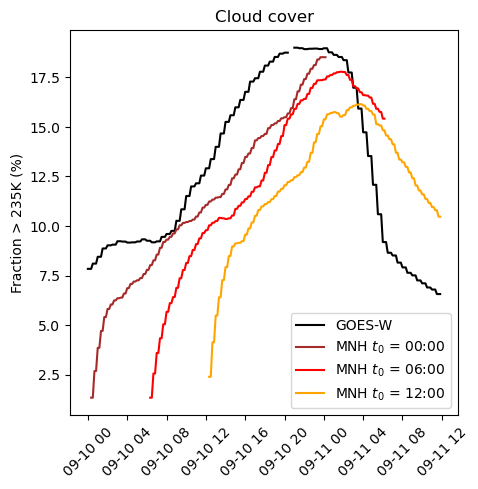

In [244]:
##-- Display

fig,ax = plt.subplots(figsize=(5,5))

# GOES-W
ax.plot(time_array,frac_array[0]*100,'k',label='GOES-W')
# t_0
ax.plot(time_array,frac_array[1]*100,'brown',label=r'MNH $t_0$ = 00:00')
# t_0 + 6h
ax.plot(time_array,frac_array[2]*100,'red',label=r'MNH $t_0$ = 06:00')
# t_0 + 12h
ax.plot(time_array,frac_array[3]*100,'orange',label=r'MNH $t_0$ = 12:00')

# legend
ax.legend()
# axes
ax.set_ylabel('Fraction > 235K (%)')
plt.xticks(rotation=45)
# title
ax.set_title('Cloud cover')

# save
plt.savefig(os.path.join(fig_dir,'RC5_frac_Tb_235_GOESW_t0_t6_t12.pdf'),bbox_inches='tight')